In [1]:
import pandas as pd

df = pd.read_csv('../data/DataCoSupplyChainDataset.csv', encoding='latin-1')
df.shape

(180519, 53)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

In [3]:
list(df.columns)

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Image',
 'Product Name',
 'Product P

In [4]:
for col in df.columns:
    print(col)

Type
Days for shipping (real)
Days for shipment (scheduled)
Benefit per order
Sales per customer
Delivery Status
Late_delivery_risk
Category Id
Category Name
Customer City
Customer Country
Customer Email
Customer Fname
Customer Id
Customer Lname
Customer Password
Customer Segment
Customer State
Customer Street
Customer Zipcode
Department Id
Department Name
Latitude
Longitude
Market
Order City
Order Country
Order Customer Id
order date (DateOrders)
Order Id
Order Item Cardprod Id
Order Item Discount
Order Item Discount Rate
Order Item Id
Order Item Product Price
Order Item Profit Ratio
Order Item Quantity
Sales
Order Item Total
Order Profit Per Order
Order Region
Order State
Order Status
Order Zipcode
Product Card Id
Product Category Id
Product Description
Product Image
Product Name
Product Price
Product Status
shipping date (DateOrders)
Shipping Mode


In [5]:
print(len(df.columns))
for i, col in enumerate(df.columns):
    print(i, col)

53
0 Type
1 Days for shipping (real)
2 Days for shipment (scheduled)
3 Benefit per order
4 Sales per customer
5 Delivery Status
6 Late_delivery_risk
7 Category Id
8 Category Name
9 Customer City
10 Customer Country
11 Customer Email
12 Customer Fname
13 Customer Id
14 Customer Lname
15 Customer Password
16 Customer Segment
17 Customer State
18 Customer Street
19 Customer Zipcode
20 Department Id
21 Department Name
22 Latitude
23 Longitude
24 Market
25 Order City
26 Order Country
27 Order Customer Id
28 order date (DateOrders)
29 Order Id
30 Order Item Cardprod Id
31 Order Item Discount
32 Order Item Discount Rate
33 Order Item Id
34 Order Item Product Price
35 Order Item Profit Ratio
36 Order Item Quantity
37 Sales
38 Order Item Total
39 Order Profit Per Order
40 Order Region
41 Order State
42 Order Status
43 Order Zipcode
44 Product Card Id
45 Product Category Id
46 Product Description
47 Product Image
48 Product Name
49 Product Price
50 Product Status
51 shipping date (DateOrders)
52

In [6]:
[col for col in df.columns if 'date' in col.lower() or 'order' in col.lower() or 'city' in col.lower()]

['Benefit per order',
 'Customer City',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'shipping date (DateOrders)']

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

df[['order date (DateOrders)', 'shipping date (DateOrders)']].dtypes

order date (DateOrders)       datetime64[us]
shipping date (DateOrders)    datetime64[us]
dtype: object

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['actual_delay_days'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['actual_delay_days'].describe()

count    180519.000000
mean          3.471856
std           1.670471
min           0.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: actual_delay_days, dtype: float64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['is_late'] = (df['actual_delay_days'] > df['Days for shipment (scheduled)']).astype(int)
df['is_late'].value_counts()

is_late
1    98743
0    81776
Name: count, dtype: int64

In [13]:
pd.crosstab(df['is_late'], df['Late_delivery_risk'])

Late_delivery_risk,0,1
is_late,,
0,77322,4454
1,4220,94523


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

Matplotlib is building the font cache; this may take a moment.


In [15]:
delay_by_mode = df.groupby('Shipping Mode')['is_late'].mean().sort_values(ascending=False)
delay_by_mode


Shipping Mode
First Class       1.000000
Second Class      0.797308
Standard Class    0.397682
Same Day          0.000000
Name: is_late, dtype: float64

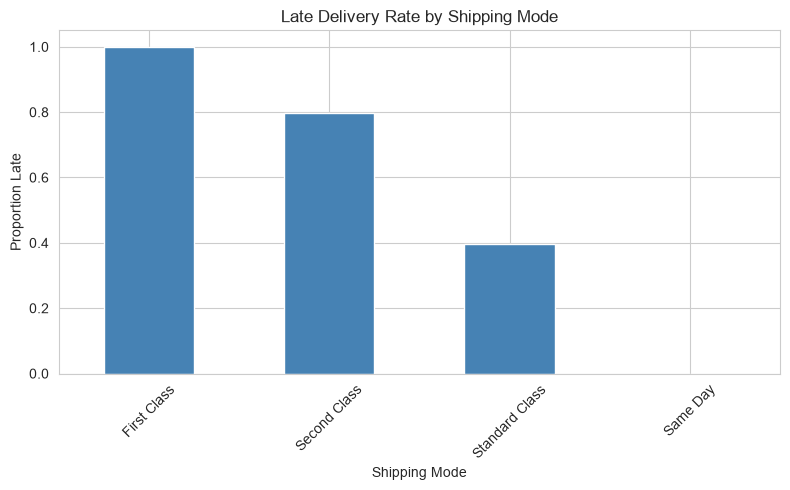

In [16]:
delay_by_mode.plot(kind='bar', figsize=(8,5), color='steelblue')
plt.title('Late Delivery Rate by Shipping Mode')
plt.ylabel('Proportion Late')
plt.xlabel('Shipping Mode')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
df.groupby('Shipping Mode')['Days for shipment (scheduled)'].mean()

Shipping Mode
First Class       1.0
Same Day          0.0
Second Class      2.0
Standard Class    4.0
Name: Days for shipment (scheduled), dtype: float64

In [18]:
df.groupby('Shipping Mode')['actual_delay_days'].mean()

Shipping Mode
First Class       2.000000
Same Day          0.000000
Second Class      3.990828
Standard Class    3.995907
Name: actual_delay_days, dtype: float64

In [19]:
delay_by_region = df.groupby('Order Region')['is_late'].mean().sort_values(ascending=False)
delay_by_region

Order Region
Central Africa     0.592725
Southeast Asia     0.559912
South Asia         0.559695
Western Europe     0.558191
Eastern Europe     0.558163
South of  USA      0.556242
West Asia          0.553503
East Africa        0.552376
East of USA        0.550542
US Center          0.550025
Central America    0.548005
Central Asia       0.547920
South America      0.544225
Northern Europe    0.541769
Eastern Asia       0.540247
West of USA        0.539847
Oceania            0.534194
Southern Europe    0.532605
North Africa       0.532488
Caribbean          0.529815
West Africa        0.526515
Southern Africa    0.515990
Canada             0.507821
Name: is_late, dtype: float64

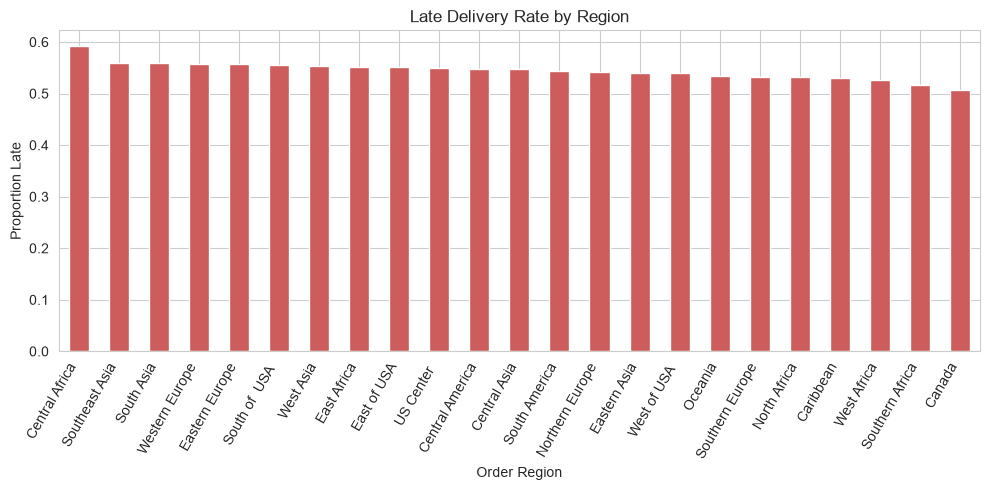

In [20]:
delay_by_region.plot(kind='bar', figsize=(10,5), color='indianred')
plt.title('Late Delivery Rate by Region')
plt.ylabel('Proportion Late')
plt.xlabel('Order Region')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()